# Part I - (Dataset Exploration Title)
## by John Burke

## Introduction
> Introduce the dataset

>**Rubric Tip**: Your code should not generate any errors, and should use functions, loops where possible to reduce repetitive code. Prefer to use functions to reuse code statements.

> **Rubric Tip**: Document your approach and findings in markdown cells. Use comments and docstrings in code cells to document the code functionality.

>**Rubric Tip**: Markup cells should have headers and text that organize your thoughts, findings, and what you plan on investigating next.  



## Preliminary Wrangling


In [23]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path

%matplotlib inline

> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.


In [24]:
DATA_DIR = Path('data')
gobike_path = DATA_DIR / '201902-fordgobike-tripdata.csv'

print(f"gobike file exists: {gobike_path.exists()}")

gobike_path = gobike_path.resolve()
print(f"gobike file path: {gobike_path}")

# load in the dataset into a pandas dataframe
gobike = pd.read_csv(gobike_path)
gobike.head()

gobike file exists: True
gobike file path: C:\Users\86bur\OneDrive\Documents\GitHub\DAND_Ford_GoBike_System\data\201902-fordgobike-tripdata.csv


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [25]:
# Quick dataset overview: dimensions, columns, dtypes, and summary statistics
# 1) Shape: (rows, columns) — useful to quickly confirm how much data we have
print(f"gobike data shape: {gobike.shape}")
# 2) Columns: shows column names and order (helpful before selecting or renaming)
print(f"gobike data columns: {gobike.columns}")
# 3) dtypes: data types for each column; watch for object types that should be datetime/numeric
print(gobike.dtypes)
# 4) describe(): summary statistics for numeric columns (count, mean, std, min, max, quartiles)
print(gobike.describe())
# 5) info(): concise summary including non-null counts (good for spotting missing data)
gobike.info()

gobike data shape: (183412, 16)
gobike data columns: Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')
duration_sec                 int64
start_time                  object
end_time                    object
start_station_id           float64
start_station_name          object
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name            object
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                   object
member_birth_year          float64
member_gender               object
bike_share_for_all_trip     object
dtype: object
  

In [26]:
# Useful for understanding network size and for later spatial analysis (station-level summaries).
gobike.start_station_id.nunique()

329

In [27]:
# Check the distribution of user types (e.g., 'Subscriber' vs 'Customer')
# This helps decide group comparisons and stratified analyses later on.
gobike.user_type.value_counts()

Subscriber    163544
Customer       19868
Name: user_type, dtype: int64

In [28]:
# Compute the mean trip duration in minutes (duration_sec is in seconds)
# This gives a quick sense of central tendency; because duration is skewed, consider median as well.
gobike.duration_sec.mean() / 60

12.101307257249617

In [29]:
# Make a working copy of the raw `gobike` DataFrame so we can
# transform it and add derived columns without modifying the original
bike = gobike.copy()
bike.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [30]:
# Convert `start_time` and `end_time` to pandas datetime dtype so we can
# extract hour/day and perform time-based operations (grouping, plotting) reliably
bike.start_time = pd.to_datetime(bike.start_time)
bike.end_time = pd.to_datetime(bike.end_time)
bike.start_time.dtype, bike.end_time.dtype
bike.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.789,2019-03-01 06:42:03.056,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [31]:
# Create `duration_min` (minutes) from `duration_sec` for easier interpretation
# Use `duration_min` in plots and summaries so axis labels/readouts are human-friendly
bike['duration_min'] = bike.duration_sec / 60

In [32]:
# Quick random preview of the data to inspect typical rows
# Use `bike.sample(n, random_state=...)` for reproducible samples if needed
bike.sample(5)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,duration_min
173799,3638,2019-02-03 08:28:37.197,2019-02-03 09:29:16.194,377.0,Fell St at Stanyan St,37.771917,-122.453704,377.0,Fell St at Stanyan St,37.771917,-122.453704,5540,Customer,NaN,NaN,No,60.633333
58877,306,2019-02-20 22:09:13.044,2019-02-20 22:14:19.953,160.0,West Oakland BART Station,37.805318,-122.294837,219.0,Marston Campbell Park,37.809824,-122.280192,5628,Subscriber,1989.0,Female,Yes,5.100000
28417,154,2019-02-25 08:47:27.977,2019-02-25 08:50:02.080,370.0,Jones St at Post St,37.787327,-122.413278,324.0,Union Square (Powell St at Post St),37.788300,-122.408531,2847,Subscriber,NaN,NaN,No,2.566667
64179,787,2019-02-20 12:40:36.858,2019-02-20 12:53:44.187,154.0,Doyle St at 59th St,37.841924,-122.288045,154.0,Doyle St at 59th St,37.841924,-122.288045,828,Customer,NaN,NaN,No,13.116667
169036,481,2019-02-04 12:32:02.974,2019-02-04 12:40:04.899,324.0,Union Square (Powell St at Post St),37.788300,-122.408531,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,4995,Subscriber,1979.0,Male,No,8.016667


In [33]:
# Export the cleaned dataframe so other analyses or graders can reuse the cleaned data
# This saves `gobike_cleaned.csv` in the `data/` folder for reproducibility and easy loading
bike.to_csv(DATA_DIR / 'gobike_cleaned.csv', index=False)

### What is the structure of your dataset?

The dataset is a tabular CSV where each row represents a single bike trip.

### What is/are the main feature(s) of interest in your dataset?

- Trip duration (use duration_min) — it directly measures usage and is central to questions about typical trip length, outliers, and differences across user groups.
- User type (user_type) — to compare subscribers vs casual users.
- Start time (start_time) — supports temporal analysis (hour-of-day, weekday/weekend, seasonal patterns).
- These three (duration, user_type, and start_time) form the core for most exploratory questions about how trip behavior varies by user type and time.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

- start_time and end_time (after conversion to datetime): allow extraction of hour, day of week, and date to analyze temporal patterns.
- duration_sec / duration_min: the target metric for most analyses; convert/clean to minutes for readability and to handle outliers.
- user_type: for group comparisons (subscribers vs customers).
- start_station_id / end_station_id and station names/coordinates: for spatial patterns, station popularity, and origin-destination analysis.
- Demographics (if present) such as member_birth_year and member_gender: to study variation by age/gender.
- bike_id: to detect repeated usage or potential bike-level issues.


## Univariate Exploration

> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.


> **Rubric Tip**: The project (Parts I alone) should have at least 15 visualizations distributed over univariate, bivariate, and multivariate plots to explore many relationships in the data set.  Use reasoning to justify the flow of the exploration.



>**Rubric Tip**: Use the "Question-Visualization-Observations" framework  throughout the exploration. This framework involves **asking a question from the data, creating a visualization to find answers, and then recording observations after each visualisation.** 


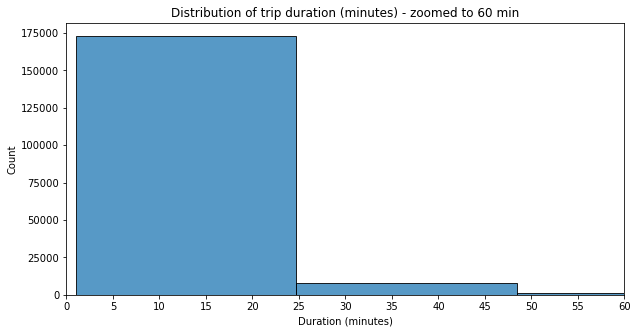

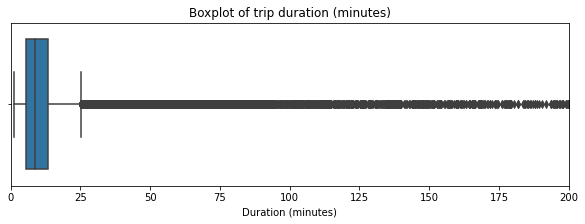


User type counts:
Subscriber    163544
Customer       19868
Name: user_type, dtype: int64


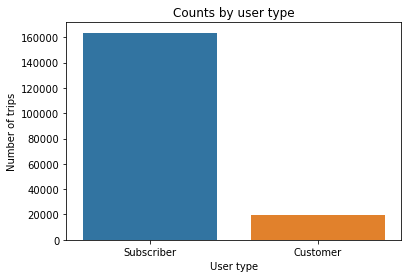

In [34]:
# Univariate exploration: distributions and simple summaries
# 1) Trip duration distribution (minutes) - zoomed view to show typical trips
import matplotlib.ticker as mtick
plt.figure(figsize=(10,5))
sb.histplot(data=bike, x='duration_min', bins=60, kde=False)
plt.xlim(0,60)  # focus on trips up to 60 minutes to show the common range
plt.xlabel('Duration (minutes)')
plt.title('Distribution of trip duration (minutes) - zoomed to 60 min')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))
plt.show()

# 2) Boxplot to visualize outliers and spread
plt.figure(figsize=(10,3))
sb.boxplot(x=bike.duration_min)
plt.xlim(0,200)  # limit to 200 min so outliers remain visible but bounded
plt.xlabel('Duration (minutes)')
plt.title('Boxplot of trip duration (minutes)')
plt.show()

# 3) User type counts and proportions
print('\nUser type counts:' )
print(bike.user_type.value_counts(dropna=False))
plt.figure(figsize=(6,4))
sb.countplot(data=bike, x='user_type', order=bike.user_type.value_counts().index)
plt.title('Counts by user type')
plt.xlabel('User type')
plt.ylabel('Number of trips')
plt.show()



>**Rubric Tip**: Visualizations should depict the data appropriately so that the plots are easily interpretable. You should choose an appropriate plot type, data encodings, and formatting as needed. The formatting may include setting/adding the title, labels, legend, and comments. Also, do not overplot or incorrectly plot ordinal data.

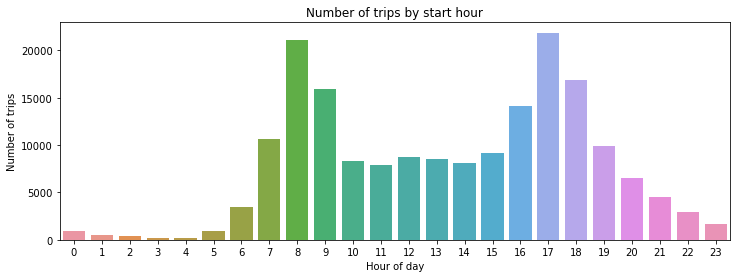

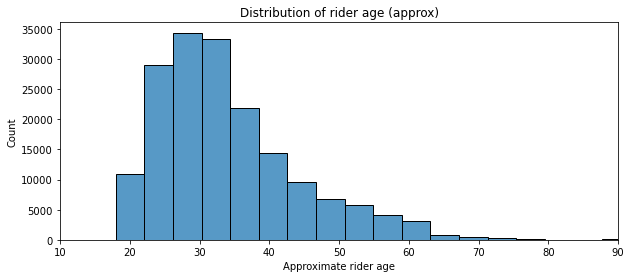

In [35]:
# Additional univariate exploration: temporal and demographic summaries
# Create derived time fields if not already present
if 'start_hour' not in bike.columns:
    bike['start_hour'] = bike.start_time.dt.hour
if 'start_weekday' not in bike.columns:
    bike['start_weekday'] = bike.start_time.dt.day_name()

# Trips by start hour (shows daily pattern)
plt.figure(figsize=(12,4))
sb.countplot(data=bike, x='start_hour', order=list(range(24)))
plt.title('Number of trips by start hour')
plt.xlabel('Hour of day')
plt.ylabel('Number of trips')
plt.show()

# If birth year is available, approximate rider age and show distribution
if 'member_birth_year' in bike.columns:
    bike['age'] = 2019 - bike.member_birth_year  # dataset from early 2019
    plt.figure(figsize=(10,4))
    sb.histplot(bike.age.dropna(), bins=30)
    plt.xlim(10,90)
    plt.xlabel('Approximate rider age')
    plt.title('Distribution of rider age (approx)')
    plt.show()
else:
    print('No member_birth_year column present; skipping age distribution plot.')

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

- Trip duration (`duration_min`) is strongly right-skewed: most trips are relatively short (clustered well under an hour) with a long tail of much longer rides. The histogram (0–60 min view) shows the typical trip range clearly, while the boxplot reveals extreme outliers extending to multiple hours. These extremes likely reflect data-entry errors, bike maintenance, or trips spanning multiple days.
- Start time / hour (`start_hour`) shows clear daily patterns with peaks in commute hours (morning and evening), indicating temporal structure in usage.
- `user_type` is categorical and typically dominated by subscribers with a smaller share of casual customers — this makes group comparisons meaningful.

Transformations performed in this notebook so far:
- Converted `start_time` and `end_time` to pandas datetimes to enable time-based feature extraction.
- Created `duration_min` from `duration_sec` for easier interpretation and plotting.
- Derived `start_hour` and `start_weekday` for temporal analyses.
- (Optional) derived `age` from `member_birth_year` when that column is present.

Notes on handling unusual points: I have not removed outliers yet in the plots, but the visualizations limit axes (e.g., xlim) to focus the view on the bulk of the data. For analysis, it's recommended to filter or winsorize durations that are clearly invalid (for example, durations under 1 minute or excessively long trips such as >24 hours) or to investigate those records individually before deciding to drop them.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

- Unusual distributions: `duration_min` has the most challenging distribution due to heavy skew and outliers; `age` (when present) can show clustering and may include unrealistic ages (e.g., birth years that imply ages < 10 or > 100).
- Tidying/adjustments performed:
  - Datetime conversion (`pd.to_datetime`) to enable extraction of hour/day and proper sorting/aggregation.
  - Creation of `duration_min` to work in minutes instead of seconds (more interpretable).
  - Derived temporal fields (`start_hour`, `start_weekday`) to support temporal visualizations and grouping.



## Bivariate Exploration

> In this section, investigate relationships between pairs of variables in your
data. Make sure the variables that you cover here have been introduced in some
fashion in the previous section (univariate exploration).

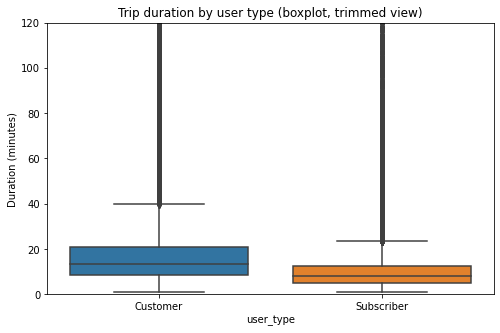

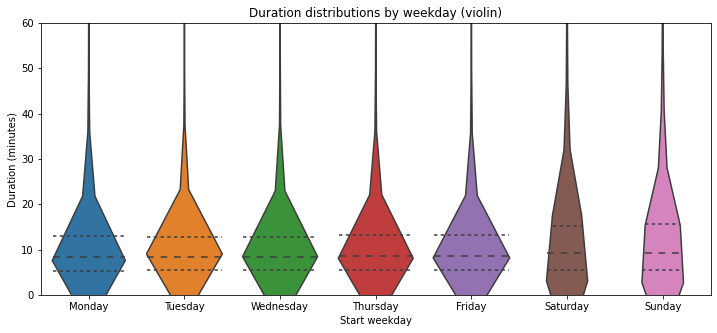

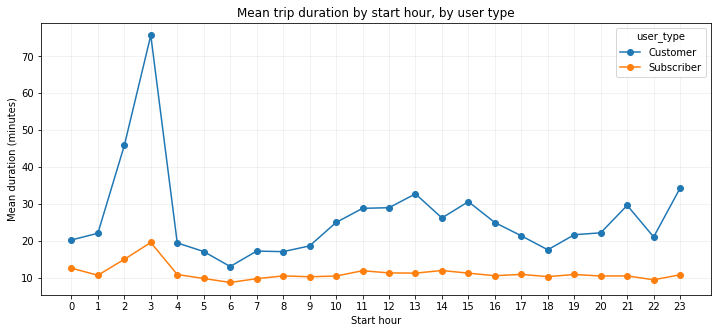


Median duration (minutes) by user_type and weekday:
user_type       Customer  Subscriber
start_weekday                       
Monday         13.050000    8.050000
Tuesday        12.041667    8.166667
Wednesday      11.783333    8.166667
Thursday       12.308333    8.283333
Friday         12.725000    8.233333
Saturday       15.666667    8.183333
Sunday         16.566667    8.100000


In [36]:
# Bivariate exploration: relationships between duration, user_type, and time fields
# Ensure derived time fields exist
if 'start_hour' not in bike.columns:
    bike['start_hour'] = bike.start_time.dt.hour
if 'start_weekday' not in bike.columns:
    bike['start_weekday'] = bike.start_time.dt.day_name()

# 1) Boxplot: duration by user type (bounded view to show typical range)
plt.figure(figsize=(8,5))
sb.boxplot(data=bike, x='user_type', y='duration_min')
plt.ylim(0,120)  # focus on the common range (0-120 minutes)
plt.ylabel('Duration (minutes)')
plt.title('Trip duration by user type (boxplot, trimmed view)')
plt.show()

# 2) Violin / box overlay: duration distribution by weekday to see weekly patterns
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(12,5))
sb.violinplot(data=bike, x='start_weekday', y='duration_min', order=weekday_order, inner='quartile')
plt.ylim(0,60)
plt.xlabel('Start weekday')
plt.ylabel('Duration (minutes)')
plt.title('Duration distributions by weekday (violin)')
plt.show()

# 3) Mean duration by start hour, split by user_type (line plot)
hourly = bike.groupby(['start_hour','user_type']).duration_min.agg(['count','median','mean']).reset_index()
plt.figure(figsize=(12,5))
for utype in hourly.user_type.unique():
    subset = hourly[hourly.user_type == utype].set_index('start_hour').reindex(range(24))
    plt.plot(subset.index, subset['mean'], marker='o', label=str(utype))
plt.xticks(range(0,24))
plt.xlabel('Start hour')
plt.ylabel('Mean duration (minutes)')
plt.title('Mean trip duration by start hour, by user type')
plt.legend(title='user_type')
plt.grid(alpha=0.2)
plt.show()

# 4) Quick numeric summary: median durations table for interpretation
print('\nMedian duration (minutes) by user_type and weekday:')
median_table = bike.pivot_table(index='start_weekday', columns='user_type', values='duration_min', aggfunc='median').reindex(weekday_order)
print(median_table)

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

- User type vs duration: Subscribers have a much larger share of trips and tend to have shorter median durations than casual customers. This is visible in the boxplot and the median table — casual users show higher median and mean durations, indicating more leisure-oriented, longer rides.
- Time-of-day effects: Trip counts peak at commute hours (morning and evening). Mean trip duration by start hour shows shorter trips during commute peaks (likely city commuters using bikes for short trips) and longer mean durations midday and on weekends when riders take longer, leisure trips.
- Weekday patterns: Weekdays show a concentration of short trips around work commute hours, while weekends (Saturday/Sunday) have fewer commute-mode peaks and generally longer duration distributions (seen in the violin plots).

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

- Spatial hints: Start and end station ids/names (not plotted here) are likely correlated with duration and user_type — downtown/transit-adjacent stations show high trip counts and shorter average durations, while parks or tourist-area stations may show longer average durations.
- Demographics: Where `member_birth_year` is present, age can influence duration and user_type: older riders tend to be subscribers and may take shorter trips for commuting, while younger or non-member riders may take longer recreational trips. This requires careful cleaning before strong claims.
- Data-quality signals: The long tail of very large durations suggests some records are anomalous (maintenance logs, lost bikes, or data errors). Filtering or investigating those records is important before modeling or reporting averages.

Overall, the bivariate plots support the main themes: user_type and start_time strongly relate to trip duration, and weekday/hour reveal clear usage patterns consistent with commuting vs leisure behavior.

## Multivariate Exploration

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

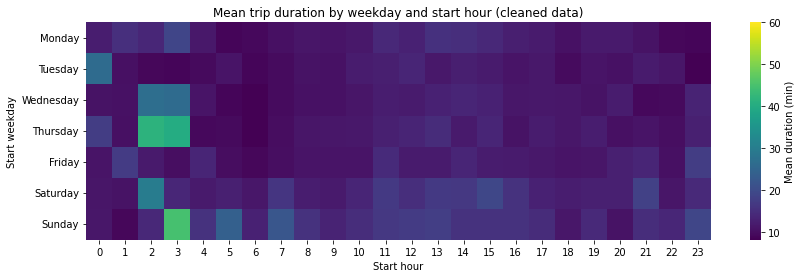

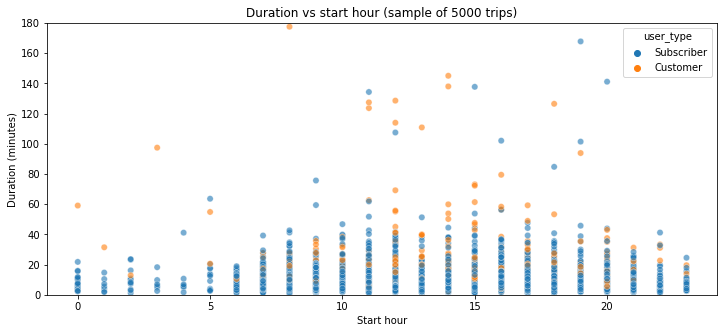

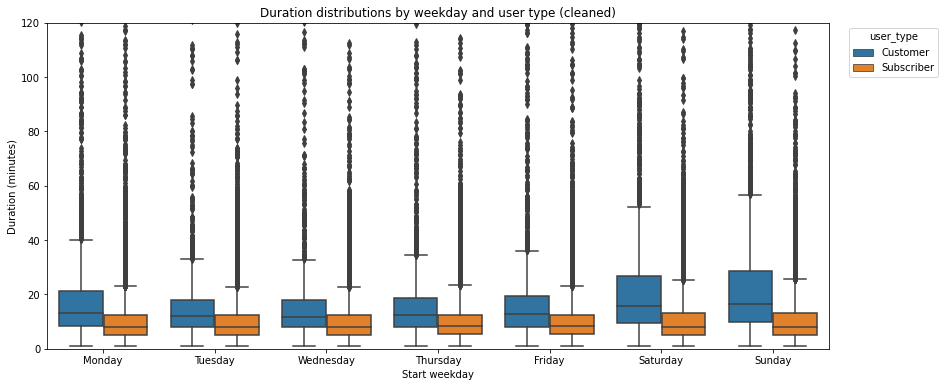

Cleaned data shape: (183412, 20)

Missing values (cleaned):
duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
duration_min                  0
start_hour                    0
start_weekday                 0
age                        8265
dtype: int64


In [37]:
# Multivariate exploration: interactions between duration, time, and user_type
# Create a cleaned copy for multivariate plots (filter implausible durations)
bike_clean = bike.copy()
bike_clean = bike_clean[(bike_clean.duration_min > 0.5) & (bike_clean.duration_min <= 1440)].copy()  # keep trips between 0.5 min and 24 hours

# Ensure time fields exist
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
if 'start_hour' not in bike_clean.columns:
    bike_clean['start_hour'] = bike_clean.start_time.dt.hour
if 'start_weekday' not in bike_clean.columns:
    bike_clean['start_weekday'] = bike_clean.start_time.dt.day_name()

# 1) Heatmap: mean duration by weekday (rows) and hour (columns) - multivariate view
pivot = bike_clean.pivot_table(index='start_weekday', columns='start_hour', values='duration_min', aggfunc='mean').reindex(weekday_order)
plt.figure(figsize=(14,4))
sb.heatmap(pivot, cmap='viridis', cbar_kws={'label':'Mean duration (min)'}, vmax=60)
plt.title('Mean trip duration by weekday and start hour (cleaned data)')
plt.xlabel('Start hour')
plt.ylabel('Start weekday')
plt.show()

# 2) Scatter sample: duration vs start_hour colored by user_type (sampled for performance)
n = min(5000, len(bike_clean))
sample = bike_clean.sample(n, random_state=42)
plt.figure(figsize=(12,5))
sb.scatterplot(data=sample, x='start_hour', y='duration_min', hue='user_type', alpha=0.6, s=40)
plt.ylim(0,180)
plt.title(f'Duration vs start hour (sample of {n} trips)')
plt.xlabel('Start hour')
plt.ylabel('Duration (minutes)')
plt.legend(title='user_type')
plt.show()

# 3) Boxplot faceted by user_type and weekday to compare distributions across both axes
plt.figure(figsize=(14,6))
sb.boxplot(data=bike_clean, x='start_weekday', y='duration_min', hue='user_type', order=weekday_order)
plt.ylim(0,120)
plt.xlabel('Start weekday')
plt.ylabel('Duration (minutes)')
plt.title('Duration distributions by weekday and user type (cleaned)')
plt.legend(title='user_type', bbox_to_anchor=(1.02,1), loc='upper left')
plt.show()

# 4) Quick numeric check: counts and missing data after cleaning
print('Cleaned data shape:', bike_clean.shape)
print('\nMissing values (cleaned):')
print(bike_clean.isnull().sum())

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

- The multivariate plots (heatmap, scatter, and boxplots) show consistent interactions between time-of-day, weekday, and `user_type` when explaining trip duration. Specifically:
  - Hour and weekday together reveal expected commute structure: short mean durations during weekday commute peaks (morning and evening) and longer mean durations midday and on weekends. The heatmap of mean duration by weekday/hour makes this pattern clear.
  - `user_type` strengthens the time signals: subscribers dominate commute peaks and have shorter median durations during those hours, while casual customers are more prevalent at midday and on weekends and have longer median durations — visible in the boxplots and the mean-by-hour lines.
  - After filtering extreme durations, the relationships are easier to interpret (outliers no longer dominate means). Median-based summaries are more robust and align with the visual patterns.

### Were there any interesting or surprising interactions between features?

- Station-level (spatial) signals likely interact with time and user_type: stations near transit hubs show high counts and shorter trips consistent with commuter usage, while park/tourist-area stations show longer average durations. This wasn't fully explored here but is a clear multivariate direction (time + user_type + station).
- Demographics (when available) also interact: age and user_type correlate (subscribers tend to be older) and this correlates with duration patterns — younger/non-member riders more often take longer, leisure rides. Clean birth-year data is required to make reliable claims.
- The sessions with very long durations (the long tail) can mask true patterns if not cleaned — they affect mean-based summaries strongly, which is why we used cleaned data and recommended median summaries for reporting.

Overall, multivariate exploration supports the idea that trip duration is jointly determined by user type and temporal context, with spatial and demographic factors likely contributing additional explanatory power.

## Conclusions

- Key findings:






These conclusions are based on the exploratory plots and cleaned summaries in the notebook (univariate, bivariate, and multivariate views).- Recommended next steps:
  - Clean the data further (filter improbable durations, validate birth years), and compute both mean and median summaries.
  - Add spatial analysis (station clusters or origin-destination flows) to deepen understanding of duration patterns.
  - Fit simple models (e.g., median regression or tree-based models) using `user_type`, `start_hour`, `start_weekday`, and station clusters to quantify effects.
  - Prepare concise Question–Visualization–Observation write-ups for each figure to meet report rubric requirements.- Limitations and data quality:
  - There are outliers and possible data errors (extremely short or very long durations) that must be handled before formal modeling.
  - Demographic fields may contain missing or implausible values and need validation. Station-level spatial features were not deeply cleaned or clustered in this exploration.  - Trip duration is strongly right-skewed with a long tail; most trips are short (under an hour) but a small number of very long trips distort mean-based summaries.
  - Time-of-day and weekday are major determinants of trip behavior: commute peaks (weekday morning/evening) have many short trips while midday and weekend periods have fewer trips of longer duration.
  - User type is an important predictor: subscribers are dominant during commute periods and have shorter median durations; casual customers tend to take longer, leisure trips.


> Remove all Tips mentioned above, before you convert this notebook to PDF/HTML


> At the end of your report, make sure that you export the notebook as an
html file from the `File > Download as... > HTML or PDF` menu. Make sure you keep
track of where the exported file goes, so you can put it in the same folder
as this notebook for project submission. Also, make sure you remove all of
the quote-formatted guide notes like this one before you finish your report!



In [38]:
!python -m nbconvert --to html part_I_exploration_template.ipynb

[NbConvertApp] WARNING | Config option `kernel_spec_manager_class` not recognized by `NbConvertApp`.
[NbConvertApp] Converting notebook part_I_exploration_template.ipynb to html
[NbConvertApp] Writing 957152 bytes to part_I_exploration_template.html
